<a href="https://colab.research.google.com/github/nidafatima-ai/ChoiceCraft2026/blob/main/CNN_for_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**import** **Libraries**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
transform = transforms.Compose(
    [
       transforms.ToTensor(),
       transforms.Normalize([0.5, 0.5, 0.5],  [0.5, 0.5, 0.5])
    ]
)

In [ ]:
train_dataSets = datasets.CIFAR10(
    root = "./data",
    train = True,
    download = True,
    transform = transform
)

In [ ]:
test_dataSets = datasets.CIFAR10(
    root = "./data",
    train = False,
    download = False,
    transform = transform
)

In [ ]:
train_loader = DataLoader(train_dataSets, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_dataSets, batch_size = 64, shuffle = False)

In [ ]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        # Convolution + Pooling layers
        self.conv_layers = nn.Sequential(

            # First convolution layer
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Second convolution layer
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x
model = CNN()

cross_entropy, optimizer

In [ ]:
criterian = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr = 0.001
)

Training

In [ ]:
for epoch in range(2):
    model.train()
    for images, labels in train_loader:
        pred = model(images)
        loss = criterian(pred, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

In [ ]:
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [ ]:
model.eval()
image, label = test_dataSets[0]
with torch.no_grad():
    output = model(image.unsqueeze(0))

prediction = output.argmax(1).item()

print("Predicted:", classes[prediction])
print("Actual:", classes[label])

Predicted: cat
Actual: cat


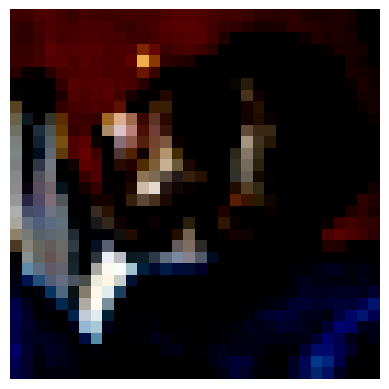

In [36]:
import matplotlib.pyplot as plt

image, label = test_dataSets[0]

plt.imshow(image.permute(1, 2, 0))
plt.axis("off")
plt.show()